# Introduction to Convolutional Neural Network and Computer Vision with TensorFlow

Computer Vision is the practice of writing alogorithm which can discover patterns in visua data. Such as the camera of self-driving car recognizing the car in front.

### Convolutional Neural Network (CNN)

> **Architecture**

* input_image - Target image for which we want to discover the pattern
* Input layer - take the image and preprocess it for further layers
>           `input_shapes = [batch_size, image_height, width_height, color_channels]`
* Convolutional layer - Extract/learns the most important features from target images
>            `Multiple, can create with tf.keras.layers.ConvXD` (X can be multiple values)
* Hidden activation - Add non-linearity to learned features (non-staright lines)
>            `Usually ReLU`
* Pooling layer - Reduces the dimensionality of learned image features
>            Average or Max `tf.keras.layers.AvgPool2D/MaxPool2D`
* Fully connected layer - Further refines learned features from convolutional layers
* Output layer - Takes learned features and outputs them in shape of target labels
>            `output_shape = [number_of_classes]`
* Output activation - Adds non-linearity to output layer
>               `sigmoid for Binary and softmax for Multiclass`



### Get the data

The image we're working with are from the Food101 dataset (101 different classes of food): https://www.kaggle.com/datasets/dansbecker/food-101

However we'vw modified it to only use two classes (pizzas 🍕 & steak 🥩) using the image  data modification notebbok: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

> 🔑 **Note**: We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work) before scaling up.

In [4]:
import zipfile

!curl -O https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  104M  100  104M    0     0  4523k      0  0:00:23  0:00:23 --:--:-- 4692k4  0:00:12  0:00:12 4697kM    0     0  4420k      0  0:00:24  0:00:15  0:00:09 4807k


In [7]:
# Unzip the downloaded file
zip_ref = zipfile.ZipFile('../../data/pizza_steak.zip')
zip_ref.extractall()
zip_ref.close()

### Inspect the data (become one with data)

A very crucial step at the begining of any machine learninf project is becoming one with data.

And for a computer vision project... this usually means visualizing many sampkles of the data.

In [13]:
!ls  ../../data/pizza_steak/train/

pizza steak


In [16]:
!ls  ../../data/pizza_steak/train/steak

1000205.jpg 1647351.jpg 2238681.jpg 2824680.jpg 3375959.jpg 417368.jpg
100135.jpg  1650002.jpg 2238802.jpg 2825100.jpg 3381560.jpg 4176.jpg
101312.jpg  165639.jpg  2254705.jpg 2826987.jpg 3382936.jpg 42125.jpg
1021458.jpg 1658186.jpg 225990.jpg  2832499.jpg 3386119.jpg 421476.jpg
1032846.jpg 1658443.jpg 2260231.jpg 2832960.jpg 3388717.jpg 421561.jpg
10380.jpg   165964.jpg  2268692.jpg 285045.jpg  3389138.jpg 438871.jpg
1049459.jpg 167069.jpg  2271133.jpg 285147.jpg  3393547.jpg 43924.jpg
1053665.jpg 1675632.jpg 227576.jpg  2855315.jpg 3393688.jpg 440188.jpg
1068516.jpg 1678108.jpg 2283057.jpg 2856066.jpg 3396589.jpg 442757.jpg
1068975.jpg 168006.jpg  2286639.jpg 2859933.jpg 339891.jpg  443210.jpg
1081258.jpg 1682496.jpg 2287136.jpg 286219.jpg  3417789.jpg 444064.jpg
1090122.jpg 1684438.jpg 2291292.jpg 2862562.jpg 3425047.jpg 444709.jpg
1093966.jpg 168775.jpg  229323.jpg  2865730.jpg 3434983.jpg 447557.jpg
1098844.jpg 1697339.jpg 2300534.jpg 2878151.jpg 3435358.jpg 461187.jpg
1100074.jp

In [17]:
!ls  ../../data/pizza_steak/train/steak | wc -l

     750


In [18]:
import os 

# Walk through pizza_steak directory which is in data directory and list number of files
for dirpath, dirnames, filenames in os.walk('../../data/pizza_steak'):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.')

There are 2 directories and 0 images in ../../data/pizza_steak.
There are 2 directories and 0 images in ../../data/pizza_steak/test.
There are 0 directories and 250 images in ../../data/pizza_steak/test/steak.
There are 0 directories and 250 images in ../../data/pizza_steak/test/pizza.
There are 2 directories and 0 images in ../../data/pizza_steak/train.
There are 0 directories and 750 images in ../../data/pizza_steak/train/steak.
There are 0 directories and 750 images in ../../data/pizza_steak/train/pizza.


In [22]:
!ls -la ../../data/pizza_steak/

total 0
drwxr-xr-x@ 4 spy  staff  128 May 23 02:09 .
drwxr-xr-x@ 4 spy  staff  128 May 23 02:09 ..
drwxr-xr-x@ 4 spy  staff  128 May 23 02:09 test
drwxr-xr-x@ 4 spy  staff  128 May 23 02:09 train


In [23]:
# another way to find how many images are in a file
num_images_steak_train = len(os.listdir('../../data/pizza_steak/train/steak'))
num_images_steak_train

750

To visulaise our imahges, let's first get the class name programmatically

In [24]:
# get the classname programmatically
import pathlib
import numpy as np

data_dir = pathlib.Path('../../data/pizza_steak/train')
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # Create a list of class_namesfrom the subdirectories

print(class_names)

['pizza' 'steak']


In [25]:
# Lets visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    '''Setup the target directories (we'll view the images from here)'''
    target_folder = target_dir+target_class
    
    # get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)
    
    # read in the image and plot it 
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image shape: {img.shape}") # shwo the shape of the image
    
    return img

    

['1632774.jpg']
Image shape: (512, 512, 3)


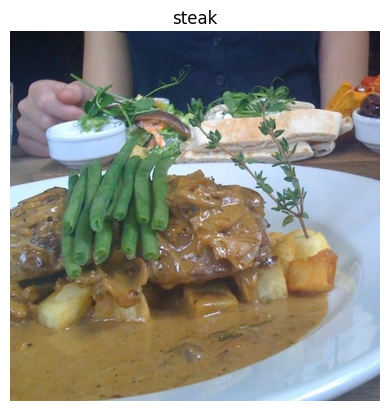

In [44]:
# view a random image from the training dataset
img = view_random_image(target_dir='../../data/pizza_steak/train/',
                        target_class="steak")

In [46]:
import tensorflow as tf
tf.constant(img)

2026-05-23 02:39:48.172356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 13,  17,  28],
        [ 14,  18,  29],
        [ 18,  18,  30],
        ...,
        [ 23,  20,  31],
        [ 21,  19,  33],
        [ 21,  19,  33]],

       [[ 12,  16,  27],
        [ 13,  17,  28],
        [ 14,  16,  28],
        ...,
        [ 23,  20,  31],
        [ 21,  19,  32],
        [ 21,  19,  33]],

       [[ 11,  18,  28],
        [ 13,  17,  28],
        [ 13,  15,  27],
        ...,
        [ 22,  19,  30],
        [ 21,  19,  32],
        [ 21,  19,  32]],

       ...,

       [[150, 125,  69],
        [148, 123,  67],
        [147, 122,  66],
        ...,
        [101, 106, 112],
        [102, 106, 117],
        [102, 106, 117]],

       [[153, 128,  72],
        [153, 128,  72],
        [153, 128,  72],
        ...,
        [106, 111, 117],
        [107, 111, 122],
        [108, 112, 123]],

       [[155, 130,  74],
        [157, 132,  76],
        [158, 133,  77],
        ...,
        [100, 105, 11

In [47]:
img.shape  # width, heigh, color_channels

(512, 512, 3)

🔑 **Note**: s we've discussed before, many machine learning models icluding neural network prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to **scale** (also referred to as **normalize**) their pixel values by dividing he image arrays by 255. (since 255 is the maximum pixel value).

In [48]:
# get all the pixel values between 0 and 1 
img / 255.0

array([[[0.05098039, 0.06666667, 0.10980392],
        [0.05490196, 0.07058824, 0.11372549],
        [0.07058824, 0.07058824, 0.11764706],
        ...,
        [0.09019608, 0.07843137, 0.12156863],
        [0.08235294, 0.0745098 , 0.12941176],
        [0.08235294, 0.0745098 , 0.12941176]],

       [[0.04705882, 0.0627451 , 0.10588235],
        [0.05098039, 0.06666667, 0.10980392],
        [0.05490196, 0.0627451 , 0.10980392],
        ...,
        [0.09019608, 0.07843137, 0.12156863],
        [0.08235294, 0.0745098 , 0.1254902 ],
        [0.08235294, 0.0745098 , 0.12941176]],

       [[0.04313725, 0.07058824, 0.10980392],
        [0.05098039, 0.06666667, 0.10980392],
        [0.05098039, 0.05882353, 0.10588235],
        ...,
        [0.08627451, 0.0745098 , 0.11764706],
        [0.08235294, 0.0745098 , 0.1254902 ],
        [0.08235294, 0.0745098 , 0.1254902 ]],

       ...,

       [[0.58823529, 0.49019608, 0.27058824],
        [0.58039216, 0.48235294, 0.2627451 ],
        [0.57647059, 0

### An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data

In [57]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# preprocess our data (scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1/255.)
valid_datagen = ImageDataGenerator(rescale=1/255.)

# Setup paths to our data directories
train_dir = '../../data/pizza_steak/train'
test_dir = '../../data/pizza_steak/test'

# Import datafrom directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode='binary',
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode='binary',
                                               seed=42)

# Build a CNN
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                                 kernel_size=3,
                                 activation='relu',
                                 input_shape=(224, 224, 3)),
    
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding='valid'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')   
])

# compile our CNN
model_1.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

# fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7280 - loss: 0.5578 - val_accuracy: 0.7680 - val_loss: 0.4853
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 995ms/step - accuracy: 0.7840 - loss: 0.4708 - val_accuracy: 0.8500 - val_loss: 0.3890
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8140 - loss: 0.4200 - val_accuracy: 0.8420 - val_loss: 0.3641
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1507s 33s/step - accuracy: 0.8307 - loss: 0.3862 - val_accuracy: 0.8600 - val_loss: 0.3635
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8593 - loss: 0.3407 - val_accuracy: 0.8020 - val_loss: 0.4388


In [59]:
# Get model 1 summary
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

📖 https://poloclub.github.io/cnn-explainer/

One of the best resources on `CNN`

### Using the same model as before

Let's replicate the model we built in previous section to see if it works with our image data.

The model we're building is from [TensorFlow playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=2,2,2,2&seed=0.47032&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)



In [60]:
# set random seed
tf.random.set_seed(42)

# create a model to replicate the TensorFlow Playground model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

# compile the model
model_2.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.5033 - loss: 0.9352 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


In [61]:
# get the summary of model 2
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

Despite having 20x more parameter than our CNN (model_1), model_1 performs terribly, lets try to improve it

In [64]:
# set random seed
tf.random.set_seed(42)

# Create the model 3
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# compile the model
model_3.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 288ms/step - accuracy: 0.6347 - loss: 2.4816 - val_accuracy: 0.7600 - val_loss: 0.5001
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 279ms/step - accuracy: 0.7027 - loss: 1.0654 - val_accuracy: 0.7800 - val_loss: 0.4909
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 300ms/step - accuracy: 0.7013 - loss: 0.9643 - val_accuracy: 0.6020 - val_loss: 2.0924
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 275ms/step - accuracy: 0.7307 - loss: 0.9028 - val_accuracy: 0.7840 - val_loss: 0.4878
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 291ms/step - accuracy: 0.7520 - loss: 0.6709 - val_accuracy: 0.7780 - val_loss: 0.4851


In [65]:
# get the summary of model 3
model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

Our CNN has 500x less parameters, so larger *trainable paraeters* are not always good, and we can safely draw conclusion that **Convolutional Neural Networks seek to sort out and learn the most important patterns in an image**. So even though these are less trainable paramters in our convolutional neural network, these are more helpful in deciphering between different *features* in an image.

In [66]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

### Binary Classification: Let's break it down:

1. Become one with the data (visualize, visualize, visualize)
2. Preprocess the data (prepare it for our model, the main step here is scaling/normalizing) and turning our data into batches
3. Create a model (Baseline model)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfies (Experiment, Experiment, Experiment)

### 1. Become one with the data

['167069.jpg']
Image shape: (512, 382, 3)
['2769168.jpg']
Image shape: (512, 512, 3)


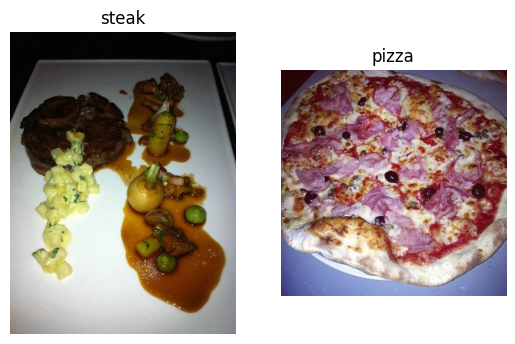

In [89]:
# visualize
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image(target_dir='../../data/pizza_steak/train/',
                              target_class="steak")
plt.subplot(1, 2, 2)
steak_img = view_random_image(target_dir='../../data/pizza_steak/train/',
                              target_class="pizza")

### 2. Preprocess the data (prepare it for our model)

In [91]:
# define directory datset path
train_dir = '../../data/pizza_steak/train'
test_dir = '../../data/pizza_steak/test'

Our next step is to turn our data into **batches**.

A batch is a small subset of data, rather than look at all -10000 images at one time, a model might only look at 32 at a time.

It does this for couple of reasons:
1. 10,000 images (or more) might not fit into memory of your processor (GPU).
2. Trying to learn the pattern in 10k images in one hit could result in the same model not being able to learn very well.

Why 32?

Because 32 is good for your Health...
> * `Yann LeCun` - founder of Convolutional Neural Network

In [96]:
# create train and test data generator  and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [98]:
# loas im our image data from directories abd turn then into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,   # target directory of iages
                                               target_size=(224, 224), # target size of images (h, w)
                                               class_mode='binary', # type of data working with
                                               batch_size=32) # size of minibatches to load data into

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                               target_size=(224, 224),
                                               class_mode='binary',
                                               batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [101]:
# get a sampleo f training dataset
images, labels = next(train_data) # get tge 'next'batches of images/labels in train_data
len(images), len(labels)

(32, 32)

In [100]:
# how many batches are there
len(train_data)

47

In [102]:
# get the first two images
images[:2], images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [103]:
# view the first batch of labels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

### 3. Create a CNN model (start with Baseline)

A baseline model is a relatively simple model or existing result that you setup when begining a machine learning experminent  and the nas you keep experimenting you try to beat baseline.

> **Note** In deep learning there is almost an infinite amount of acrchitecture you could create. So one of the best wats to get started is to start with something simple and see, if it works on the data and then introduce comolexity as required.

In [105]:
# AMke a creating ofour model little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [108]:
# create the model (this will be our baseline, a layer convolutional neural network)
model_4 = Sequential([
    Conv2D(filters=10, # number of sliding window going across an input, higher is more complex
           kernel_size=(3, 3), # size of sliding window going across an input
           strides=(1, 1), # size of step sliding window take across
           padding='same',  # if "same" output shape will be same as input shape, if "valid" output shape gets compressed
           activation='relu',
           input_shape=(224, 224, 3)),  # input layer (specify input shape)
    Conv2D(10 , 3, activation='relu'),
    Conv2D(10 , 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')  # output layer (working with binary classification so only one output)
])

In [109]:
# compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [110]:
# mdoel summary
model_4.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 484000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │       484,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,101 (1.85 MB)

 Trainable params: 486,101 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the model

In [112]:
# check the length of train and test data generator
len(train_data), len(test_data)

(47, 16)

In [114]:
# Fit the model
history_4 = model_4.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 825ms/step - accuracy: 0.6833 - loss: 0.6305 - val_accuracy: 0.8160 - val_loss: 0.3860
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 826ms/step - accuracy: 0.8307 - loss: 0.3857 - val_accuracy: 0.8080 - val_loss: 0.4094
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 828ms/step - accuracy: 0.8827 - loss: 0.3008 - val_accuracy: 0.8380 - val_loss: 0.3771
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 823ms/step - accuracy: 0.9387 - loss: 0.1990 - val_accuracy: 0.8520 - val_loss: 0.3397
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 824ms/step - accuracy: 0.9760 - loss: 0.0966 - val_accuracy: 0.8420 - val_loss: 0.3841


### 5. Evaluate our model

It looks like our model is learning something, let's evaluate it.

<Axes: title={'center': 'Model 4 evaluation'}>

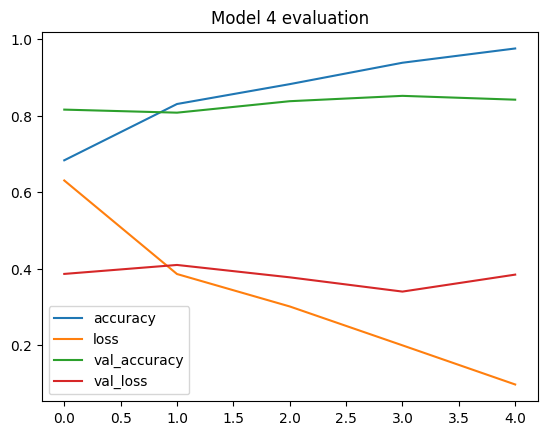

In [118]:
import pandas as pd
pd.DataFrame(history_4.history).plot(title='Model 4 evaluation')

In [121]:
# plot validation and training curves seperately
def plot_loss_curves(history):
    ''' 
    Returns seperate loss curves for traning and validation metrics.
    '''
    loss = history.history['loss']
    val_loss = history.history["val_loss"]
    
    accuracy = history.history['accuracy']
    val_accuracy = history.history["val_accuracy"]
    
    epochs = range(len(history.history["loss"])) # how many epochs did we run for
    
    # plot loss
    plt.plot(epochs, loss, label="training loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.xlabel("epochs")
    plt.title("loss")
    plt.legend()
    
    # plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label="training accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.xlabel("epochs")
    plt.title("accuracy")
    plt.legend()

> 🔑 **Note**: When a model's **validation loss starts to increase** it's likely that the model is **overfitting** the training dataset. This means, it's learnkng the pattern in training dataset *to well* and thus th model's ability to generalize to unseen data will be diminished.

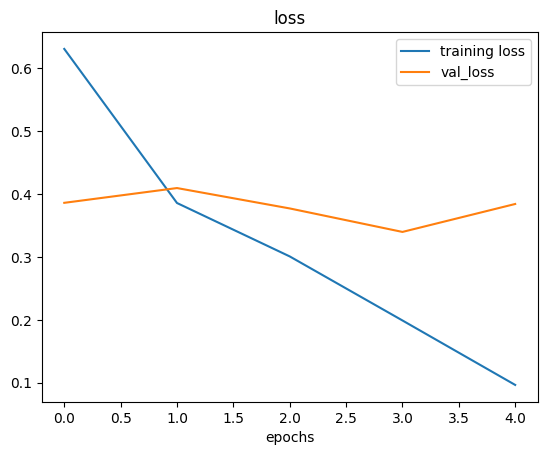

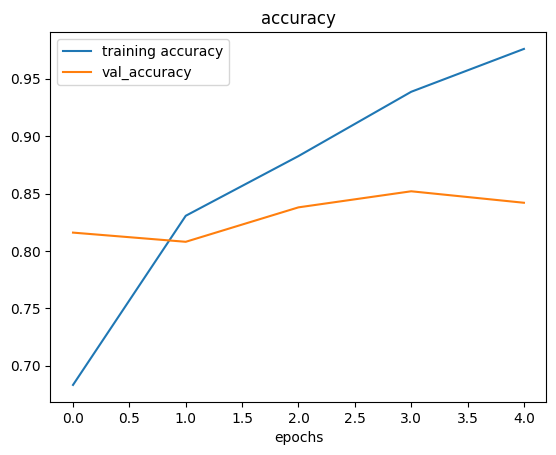

In [122]:
# loss and accuracy of model 4
plot_loss_curves(history_4)

### 6. Adjust the model parameter

Fitting a machine learning model

0. Create a baseline
1. Beat the baseline by overfitting a larger model
2. Reduce overfitting

> Ways to induce overfitting:
 * Increase the number of conv layers
 * Increase the number of conv filters
 * add another dense layer to the output of our Flatttend layer

> Reduce Overfitting:
 * Add data augumentation
 * Add regularization layers (such as MaxPool2D)
 * Add more data...

 > 🔑 **Note**: reducing overfitting is also called as *regularization*.

In [123]:
# create a new model (this will be our new baseline)
model_5 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=3),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [124]:
# compile the model
model_5.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [125]:
## fit the model
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - accuracy: 0.6647 - loss: 0.6085 - val_accuracy: 0.7900 - val_loss: 0.4654
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.7913 - loss: 0.4666 - val_accuracy: 0.8360 - val_loss: 0.3964
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.7967 - loss: 0.4472 - val_accuracy: 0.8560 - val_loss: 0.3616
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 242ms/step - accuracy: 0.8153 - loss: 0.4255 - val_accuracy: 0.8120 - val_loss: 0.4017
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 242ms/step - accuracy: 0.8233 - loss: 0.4109 - val_accuracy: 0.8640 - val_loss: 0.3342


In [126]:
model_5.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 72, 72, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 34, 34, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2890)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │         2,891 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,975 (58.50 KB)

 Trainable params: 4,991 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,984 (39.00 KB)

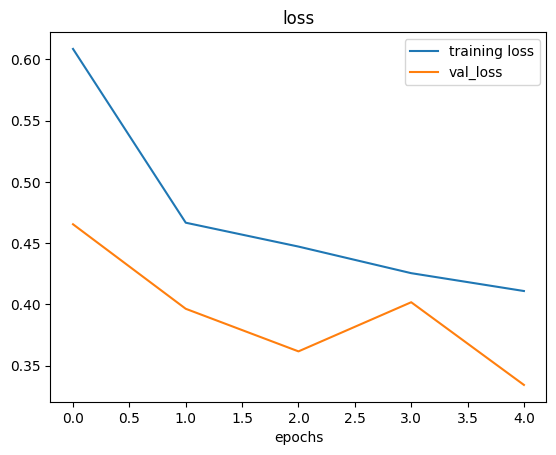

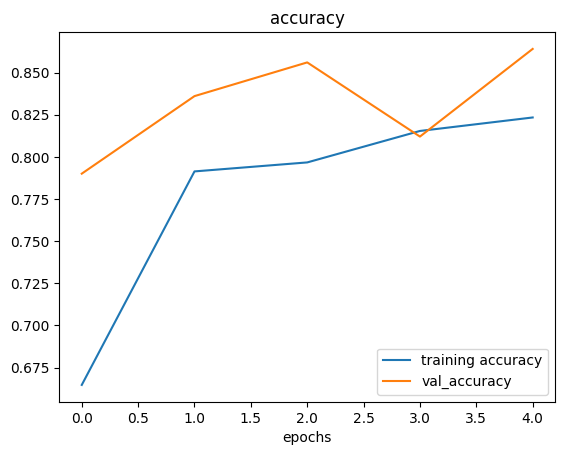

In [127]:
# plot loss curves
plot_loss_curves(history_5)

> **reducing overfitting with *data augmentation***.
>> *Opening our bag of tricks*

In [129]:
# create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.3,
                                             horizontal_flip=True)

# create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

> 🤔🤔 **Question** What is *data augmentation*?

Data augmentation is the process of altering our training data, leading it to have more diversity and in turn allowing our model to learn more generalize (hopefully) patterns. Altring might mean adjusting the rotation of an image, flipping it, cropping it or something similar to it.

Let's write some code to visualize data augmentation

In [130]:
# import data  and augment it from training directory
print("Augmented training data")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False) # for demonstration purpose only

# create non augmented train data batches
print('Non-Augmented train data')
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False)

IMG_SIZE = (224, 224)
# create non augmented train data batches
print('Non-Augmented test data')
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode='binary',
                                             shuffle=False)

Augmented training data
Found 1500 images belonging to 2 classes.
Non-Augmented train data
Found 1500 images belonging to 2 classes.
Non-Augmented test data
Found 500 images belonging to 2 classes.


> 🔑 **Note**: Data augmentation is usually only performed on the trainibg data. Using `ImageDataGenerator` built-in data augmentation parameter our images are left as they are in directories but are modified as they're loaded into the model.

Finally Let's visualize some augmented data!!!

In [131]:
# get sample data batches
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented) # note: labels aren't augmented... only data(images)


Showing image number: 29


(-0.5, 223.5, 223.5, -0.5)

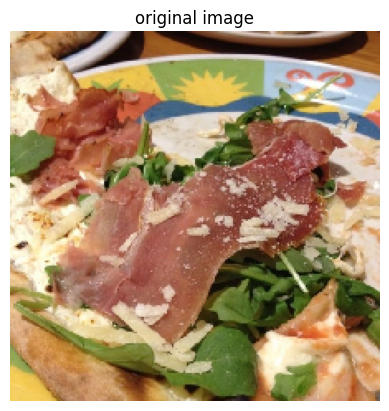

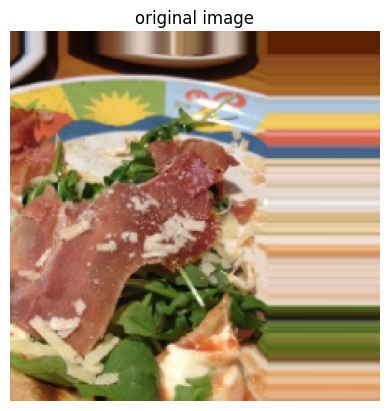

In [143]:
## show the original image and augmented image
import random
random_number = random.randint(0, 32) # our batch size is 32...
print(f'Showing image number: {random_number}')
plt.imshow(images[random_number])
plt.title(f'original image')
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f'original image')
plt.axis(False)

Now we have seen what augmented training data looks like, let's build a model and see how it learns on augmented data

In [145]:
# create the same model 
model_6 = Sequential([
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(pool_size=3),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')  
])

# compile the model
model_6.compile (loss='binary_crossentropy',
                 optimizer=Adam(),
                 metrics=['accuracy'])

# Fit the model
## fit the model
history_6 = model_6.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 491ms/step - accuracy: 0.4353 - loss: 0.7263 - val_accuracy: 0.5740 - val_loss: 0.6913
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 506ms/step - accuracy: 0.5407 - loss: 0.6930 - val_accuracy: 0.5980 - val_loss: 0.6889
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 534ms/step - accuracy: 0.5913 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.7222
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 531ms/step - accuracy: 0.5427 - loss: 0.6933 - val_accuracy: 0.6800 - val_loss: 0.6751
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 533ms/step - accuracy: 0.5873 - loss: 0.6766 - val_accuracy: 0.7900 - val_loss: 0.6288


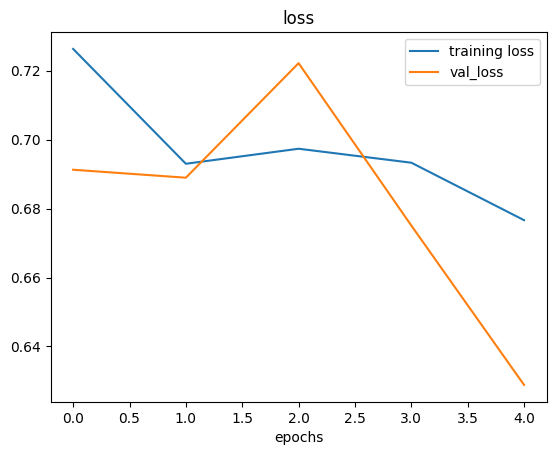

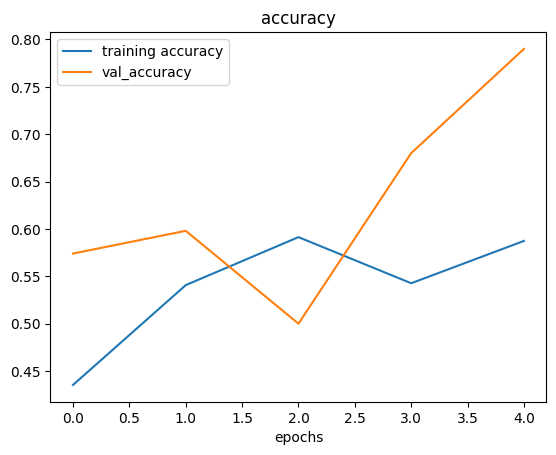

In [146]:
# check our model training curves
plot_loss_curves(history_6)

In [147]:
# import data  and augment it from training directory
print("Augmented training data")
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=True) 


Augmented training data
Found 1500 images belonging to 2 classes.


In [148]:
# create the same model (augmented and shuffle the data)
model_7 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=3),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')  
])

# compile the model
model_7.compile (loss='binary_crossentropy',
                 optimizer=Adam(),
                 metrics=['accuracy'])

# Fit the model
## fit the model
history_7 = model_7.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 496ms/step - accuracy: 0.5967 - loss: 0.6610 - val_accuracy: 0.6600 - val_loss: 0.5996
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 479ms/step - accuracy: 0.7207 - loss: 0.5610 - val_accuracy: 0.8040 - val_loss: 0.4371
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 479ms/step - accuracy: 0.7413 - loss: 0.5265 - val_accuracy: 0.8300 - val_loss: 0.3941
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step - accuracy: 0.7473 - loss: 0.5176 - val_accuracy: 0.8540 - val_loss: 0.3678
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 590ms/step - accuracy: 0.7707 - loss: 0.4847 - val_accuracy: 0.8540 - val_loss: 0.3670


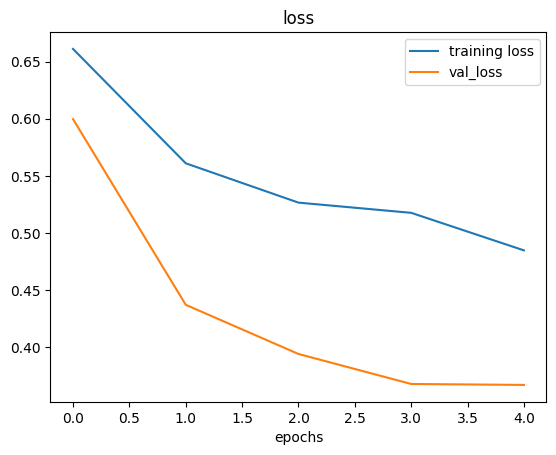

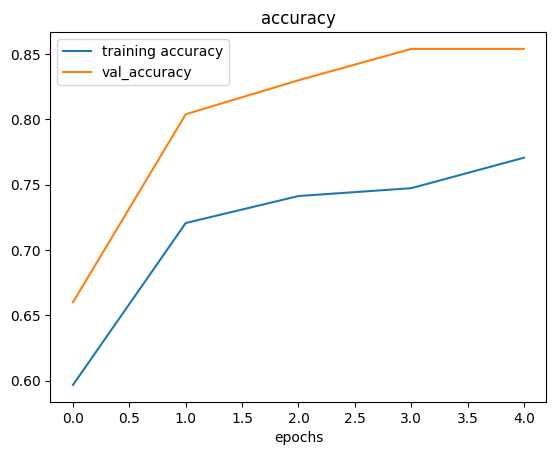

In [149]:
# plot loss curves
plot_loss_curves(history_7)

### 7. repeat until satisfied

Since we've already beaten our baseline, there are few things which we coud try to continue to improve our model:

* Increase the number of model layers (e.g. add more `Conv2D`/`MaxPool2D` layers)
* Increase the number of filters in each convolutional layer (e.g. from 10 to 32 or even 64)
* Train for longer (more epochs)
* Find an ideal learning rate
* Get more data (give the model more opportunities to learn)
* Use **transfer learning** to leaverage what another image model has learn and adjust it for our own use case.

### Make prediction with our trained model on our own custom data

In [150]:
# Classes we're working with
print(class_names)

['pizza' 'steak']


In [183]:
!rm 03-steak.jpeg

rm: 03-steak.jpeg: No such file or directory


In [192]:
!curl -L https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg -o 03-steak.jpeg

# from PIL import Image
# from IPython.display import display

# display(Image.open("03-steak.jpeg"))

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1931k  100 1931k    0     0  4332k      0 --:--:-- --:--:-- --:--:-- 4341k


In [193]:
!file 03-steak.jpeg

03-steak.jpeg: JPEG image data, JFIF standard 1.01, aspect ratio, density 72x72, segment length 16, Exif Standard: [TIFF image data, big-endian, direntries=8, manufacturer=Apple, model=iPhone 7, xresolution=126, yresolution=134, resolutionunit=2, software=13.3, datetime=2020:01:14 14:23:00], baseline, precision 8, 3024x4032, components 3


(-0.5, 3023.5, 4031.5, -0.5)

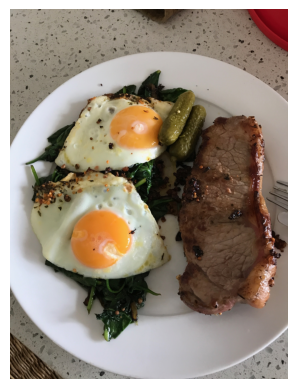

In [194]:
# View our example image

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

steak = mpimg.imread('03-steak.jpeg')
plt.imshow(steak)
plt.axis(False)

In [195]:
# check the shape of image
steak.shape

(4032, 3024, 3)

> **Note**: When you train a neral network and you want to predict with it on your own custom data, it's important that your custom data shall be preprocessed into the same format as the data on which the model is trained upon.

In [ ]:
expanded_steak = tf.expand_dims(steak, axis=0).shape

TensorShape([1, 4032, 3024, 3])

In [199]:
# create a function to import an image and resize it to be able to be use with our model
def load_and_prep_image(filename, img_shape=224):
    ''' 
    Reads the image from filename, turns it into a tensor and reshape it to 
    (img_shape, img_shape, color_channel).
    '''
    img = tf.io.read_file(filename)
    
    # decode the read file into tensor
    img = tf.image.decode_image(img)
    
    # resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    
    # rescale the image (get all values between 0 & 1)
    img = img/255.
    
    return img

In [200]:
# load in and preprocess the image
steak = load_and_prep_image('03-steak.jpeg')
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [209]:
# this is pretty large image we cannot pass directly
pred = model_7.predict(tf.expand_dims(steak, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


Looks like our custom imahe is being put through our model, however, it currently outputs a prediction probability, wouldn't it be nice if we could visualize the image as well as the model's prediction?

In [210]:
# we can index the predicted class by rounding the prediction probability and indexing it on class names
pred_class = class_names[int(tf.round(pred))]
pred_class

'steak'

In [211]:
# function to predict and plot
def pred_and_plot(model, filename, class_names=class_names):
    ''' 
    Imports and image located at filename, makes a prediction with model and plots the image with the
    predicted class as the title.
    '''
    # Import the target image abd prprocess it
    img = load_and_prep_image(filename)
    
    # make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))
    
    # get the predicted class
    pred_class = class_names[int(tf.round(pred))]
    
    # plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

In [ ]:
# test our model on a custom image
pred_and_plot(model_7, '03-steak.jpeg')

Our model works! lets try it on another image... this time pizza 🍕

In [214]:
!curl -L https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg -o 03-pizza-dad.jpeg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2807k  100 2807k    0     0  2644k      0  0:00:01  0:00:01 --:--:-- 2646k


In [215]:
!file 03-pizza-dad.jpeg

03-pizza-dad.jpeg: JPEG image data, JFIF standard 1.01, aspect ratio, density 72x72, segment length 16, Exif Standard: [TIFF image data, big-endian, direntries=10, manufacturer=Apple, model=iPhone 7, xresolution=150, yresolution=158, resolutionunit=2, software=13.5.1, datetime=2020:07:25 12:55:43], baseline, precision 8, 3024x4032, components 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


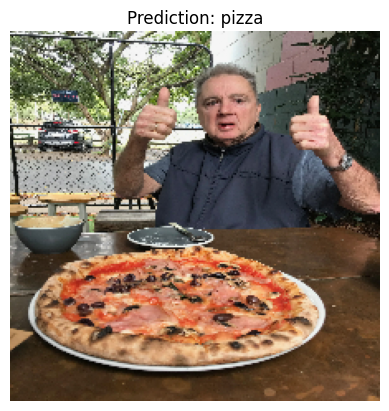

In [216]:
pred_and_plot(model_7, '03-pizza-dad.jpeg')

In [217]:
!curl -L https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg -o 03-hamburger.jpeg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3480k  100 3480k    0     0  1228k      0  0:00:02  0:00:02 --:--:-- 1228k


In [218]:
!file 03-hamburger.jpeg

03-hamburger.jpeg: JPEG image data, JFIF standard 1.01, aspect ratio, density 350x350, segment length 16, Exif Standard: [TIFF image data, big-endian, direntries=9, description=                               , manufacturer=SONY, model=ILCE-6000, xresolution=170, yresolution=178, resolutionunit=2, software=ILCE-6000 v1.00, datetime=2015:07:15 00:43:54], baseline, precision 8, 6000x4000, components 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


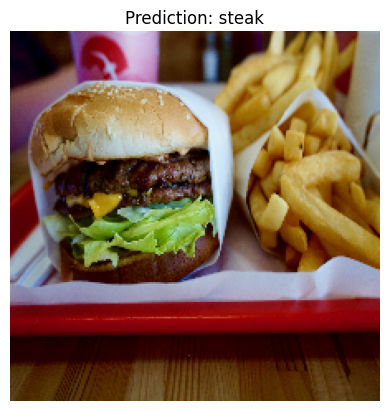

In [219]:
pred_and_plot(model_7, '03-hamburger.jpeg')